# RB Draft season features

## tl;dr

This notebook aggregates the validated RB/FB weekly Silver facts into a Draft Analysis Gold dataset at one row per `player_id + season` for the 2023–2025 regular seasons.

The output contains **498 RB/FB player-seasons and 98 columns** across three season partitions. It preserves every observed season, including 20 seasons without weekly-stat evidence. The approved eligibility rule identifies 221 seasons with at least eight observed games and 50 total opportunities for within-season percentile comparisons; ineligible rows remain in the dataset with null percentiles.

Official carries remain separate from canonical non-kneel and designed rushing opportunities. The known Dare Ogunbowale 2024 Week 15 source disagreement remains visible in reconciliation rather than being repaired. Team changes, rushing and receiving shares, efficiency rates, and full-PPR scoring are calculated from explicit components. All source reconciliation, scoring, eligibility, grain, and Parquet round-trip checks pass.

## Context & Methods

### Scope

- Seasons: 2023–2025
- Season type: regular season only
- Population: contextual RB and FB observations established in `silver_rb_week`
- Input: season-partitioned `silver_rb_week`
- Output: season-partitioned `gold/draft/rb_season_features`
- Output grain: `player_id + season`
- Default scoring: full PPR

This is the second decision-oriented Draft Gold prototype. It summarizes both rushing and receiving roles while retaining official production, canonical opportunity, team denominators, and scoring components needed to audit the features.

### Key assumptions

- Every contextual RB/FB season remains in Gold, even if it is not eligible for percentile comparisons.
- Traded players have one combined season row. `teams_played_for` preserves chronological team order, and `final_team` is the team on the latest observed week.
- The final contextual `position` prefers valid weekly stat-position evidence and otherwise uses valid snap-position evidence. `positions_observed` retains the chronological position labels seen under that rule.
- Official `rushing_attempts` remain source production. `non_kneel_rush_attempts` and `designed_rush_attempts` remain canonical PBP opportunity.
- `total_opportunities` equals canonical non-kneel rushing attempts plus targets. This same measure determines percentile eligibility.
- Opportunity shares are ratios of season totals over the player’s observed games, not averages of weekly percentages.
- Efficiency rates are null when their denominator is zero. Fantasy points remain null when a season has no weekly-stat production evidence.
- Percentiles are calculated within season only among RB/FB seasons with at least eight observed games and 50 total opportunities. Ineligible rows remain present with null percentile fields.

## Data

### 1. Set up paths, grain, and feature groups

The complete output order is declared before transformation so the persisted schema is easy to review and test.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEASONS = [2023, 2024, 2025]
RB_POSITION_LABELS = {"RB", "FB"}
GOLD_GRAIN = ["player_id", "season"]

MIN_PERCENTILE_GAMES = 8
MIN_PERCENTILE_OPPORTUNITIES = 50

# Find the repository root whether this runs from Jupyter or nbconvert.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ROADMAP.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "ROADMAP.md").exists():
            PROJECT_ROOT = parent
            break
    else:
        raise RuntimeError("Could not locate the repository root.")

SILVER_RB_WEEK_DIR = PROJECT_ROOT / "data/silver/rb_week"
GOLD_RB_SEASON_DIR = PROJECT_ROOT / "data/gold/draft/rb_season_features"

RB_INPUT_COLUMNS = [
    "player_id",
    "game_id",
    "season",
    "week",
    "season_type",
    "team",
    "display_name",
    "stats_position",
    "snap_position",
    "has_stat_record",
    "has_snap_record",
    "participated_game",
    "offensive_participant",
    "offense_snaps",
    "rushing_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "receiving_targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
    "pbp_rush_attempts",
    "pbp_non_kneel_rush_attempts",
    "pbp_designed_rush_attempts",
    "pbp_targets",
    "pbp_target_air_yards",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
    "team_targets",
    "team_air_yards",
    "team_non_kneel_rush_attempts",
    "team_designed_rush_attempts",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

IDENTITY_COLUMNS = [
    "player_id",
    "season",
    "display_name",
    "position",
    "positions_observed",
    "teams_played_for",
    "team_count",
    "final_team",
]

PARTICIPATION_COLUMNS = [
    "games_observed",
    "games_with_stat_record",
    "games_with_snap_record",
    "games_participated",
    "games_offensive_participant",
    "offense_snaps",
    "offense_snaps_per_game",
]

PRODUCTION_OPPORTUNITY_COLUMNS = [
    "total_opportunities",
    "touches",
    "rushing_attempts",
    "non_kneel_rush_attempts",
    "designed_rush_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "scrimmage_yards",
    "total_touchdowns",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
]

TEAM_DENOMINATOR_COLUMNS = [
    "team_targets",
    "team_target_air_yards",
    "team_non_kneel_rush_attempts",
    "team_designed_rush_attempts",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

SHARE_COLUMNS = [
    "rush_attempt_share",
    "designed_rush_share",
    "red_zone_rush_share",
    "goal_line_rush_share",
    "target_share",
    "target_air_yards_share",
    "red_zone_target_share",
    "goal_line_target_share",
    "end_zone_target_share",
]

EFFICIENCY_COLUMNS = [
    "rushing_yards_per_attempt",
    "rushing_first_down_rate",
    "rushing_touchdown_rate",
    "catch_rate",
    "receiving_yards_per_target",
    "receiving_yards_per_reception",
    "average_depth_of_target",
    "yards_after_catch_per_reception",
    "receiving_first_down_rate",
    "receiving_touchdown_rate",
    "scrimmage_yards_per_opportunity",
    "ppr_fantasy_points_per_opportunity",
]

PER_GAME_COLUMNS = [
    "total_opportunities_per_game",
    "touches_per_game",
    "rushing_attempts_per_game",
    "targets_per_game",
    "receptions_per_game",
    "rushing_yards_per_game",
    "receiving_yards_per_game",
    "scrimmage_yards_per_game",
    "total_touchdowns_per_game",
    "ppr_fantasy_points_per_game",
]

FANTASY_POINT_COLUMNS = [
    "receiving_fantasy_points",
    "rushing_fantasy_points",
    "special_teams_fantasy_points",
    "fumble_lost_points",
    "ppr_fantasy_points",
]

PERCENTILE_DEFINITIONS = {
    "offense_snaps_percentile": "offense_snaps",
    "total_opportunities_percentile": "total_opportunities",
    "rushing_attempts_percentile": "rushing_attempts",
    "targets_percentile": "targets",
    "rush_attempt_share_percentile": "rush_attempt_share",
    "target_share_percentile": "target_share",
    "goal_line_rush_attempts_percentile": "goal_line_rush_attempts",
    "scrimmage_yards_percentile": "scrimmage_yards",
    "scrimmage_yards_per_game_percentile": "scrimmage_yards_per_game",
    "ppr_fantasy_points_per_game_percentile": "ppr_fantasy_points_per_game",
}

GOLD_COLUMNS = [
    *IDENTITY_COLUMNS,
    *PARTICIPATION_COLUMNS,
    *PRODUCTION_OPPORTUNITY_COLUMNS,
    *TEAM_DENOMINATOR_COLUMNS,
    *SHARE_COLUMNS,
    *EFFICIENCY_COLUMNS,
    *PER_GAME_COLUMNS,
    *FANTASY_POINT_COLUMNS,
    "percentile_eligible",
    *PERCENTILE_DEFINITIONS.keys(),
]

assert len(RB_INPUT_COLUMNS) == 49
assert len(GOLD_COLUMNS) == 98
assert len(GOLD_COLUMNS) == len(set(GOLD_COLUMNS))

pd.set_option("display.max_columns", 105)

### 2. Define the calculation contracts

The contracts state the numerator and denominator choices before any features are calculated. Season shares use summed components rather than averaging weekly percentages.

In [2]:
share_contract = pd.DataFrame(
    [
        ["rush_attempt_share", "non_kneel_rush_attempts", "team_non_kneel_rush_attempts"],
        ["designed_rush_share", "designed_rush_attempts", "team_designed_rush_attempts"],
        ["red_zone_rush_share", "red_zone_rush_attempts", "team_red_zone_rush_attempts"],
        ["goal_line_rush_share", "goal_line_rush_attempts", "team_goal_line_rush_attempts"],
        ["target_share", "targets", "team_targets"],
        ["target_air_yards_share", "receiving_air_yards", "team_target_air_yards"],
        ["red_zone_target_share", "red_zone_targets", "team_red_zone_targets"],
        ["goal_line_target_share", "goal_line_targets", "team_goal_line_targets"],
        ["end_zone_target_share", "end_zone_targets", "team_end_zone_targets"],
    ],
    columns=["feature", "season_numerator", "season_denominator"],
)

efficiency_contract = pd.DataFrame(
    [
        ["rushing_yards_per_attempt", "rushing_yards", "rushing_attempts"],
        ["rushing_first_down_rate", "rushing_first_downs", "rushing_attempts"],
        ["rushing_touchdown_rate", "rushing_touchdowns", "rushing_attempts"],
        ["catch_rate", "receptions", "targets"],
        ["receiving_yards_per_target", "receiving_yards", "targets"],
        ["receiving_yards_per_reception", "receiving_yards", "receptions"],
        ["average_depth_of_target", "receiving_air_yards", "targets"],
        ["yards_after_catch_per_reception", "receiving_yards_after_catch", "receptions"],
        ["receiving_first_down_rate", "receiving_first_downs", "receptions"],
        ["receiving_touchdown_rate", "receiving_touchdowns", "targets"],
        ["scrimmage_yards_per_opportunity", "scrimmage_yards", "total_opportunities"],
    ],
    columns=["feature", "season_numerator", "season_denominator"],
)

share_contract

,feature,season_numerator,season_denominator
0,rush_attempt_share,non_kneel_rush_attempts,team_non_kneel_rush_attempts
1,designed_rush_share,designed_rush_attempts,team_designed_rush_attempts
2,red_zone_rush_share,red_zone_rush_attempts,team_red_zone_rush_attempts
3,goal_line_rush_share,goal_line_rush_attempts,team_goal_line_rush_attempts
4,target_share,targets,team_targets
5,target_air_yards_share,receiving_air_yards,team_target_air_yards
6,red_zone_target_share,red_zone_targets,team_red_zone_targets
7,goal_line_target_share,goal_line_targets,team_goal_line_targets
8,end_zone_target_share,end_zone_targets,team_end_zone_targets


In [3]:
scoring_contract = pd.DataFrame(
    [
        ["reception", 1.0],
        ["receiving yard", 0.1],
        ["receiving touchdown", 6.0],
        ["rushing yard", 0.1],
        ["rushing touchdown", 6.0],
        ["two-point conversion", 2.0],
        ["fumble lost", -2.0],
        ["special-teams touchdown", 6.0],
    ],
    columns=["event", "full_ppr_points"],
)

scoring_contract

,event,full_ppr_points
0,reception,1.0
1,receiving yard,0.1
2,receiving touchdown,6.0
3,rushing yard,0.1
4,rushing touchdown,6.0
5,two-point conversion,2.0
6,fumble lost,-2.0
7,special-teams touchdown,6.0


### 3. Load the RB Silver partitions

In [4]:
rb_week_paths = sorted(SILVER_RB_WEEK_DIR.glob("*.parquet"))

assert len(rb_week_paths) == len(SEASONS)

rb_week = pd.concat(
    [pd.read_parquet(path, columns=RB_INPUT_COLUMNS) for path in rb_week_paths],
    ignore_index=True,
)

input_summary = pd.DataFrame(
    [
        [
            "silver_rb_week",
            len(rb_week),
            62,
            len(rb_week.columns),
            len(rb_week_paths),
        ]
    ],
    columns=["input", "rows", "columns_available", "columns_selected", "files"],
)

assert set(rb_week["season"].unique()) == set(SEASONS)
input_summary

,input,rows,columns_available,columns_selected,files
0,silver_rb_week,5826,62,49,3


## Results

### 4. Validate the input grain and select regular-season observations

Postseason rows remain in Silver but do not enter the Draft season profile. The Gold population is therefore defined explicitly before aggregation.

In [5]:
SILVER_RB_GRAIN = ["player_id", "season", "week", "team"]

assert rb_week[SILVER_RB_GRAIN].notna().all().all()
assert not rb_week.duplicated(SILVER_RB_GRAIN).any()

rb_regular = (
    rb_week.loc[rb_week["season_type"].eq("REG")]
    .sort_values(["player_id", "season", "week", "team"])
    .reset_index(drop=True)
)

assert rb_regular["game_id"].notna().all()
assert not rb_regular.duplicated(SILVER_RB_GRAIN).any()
assert not rb_regular.duplicated(["player_id", "season", "game_id"]).any()

regular_population_summary = (
    rb_regular.groupby("season", dropna=False)
    .agg(
        player_weeks=("game_id", "size"),
        player_seasons=("player_id", "nunique"),
        teams=("team", "nunique"),
    )
    .reset_index()
)

regular_population_summary

,season,player_weeks,player_seasons,teams
0,2023,1847,167,32
1,2024,1849,164,32
2,2025,1846,167,32


### 5. Build season identity, position, and team context

Weekly stat position is preferred when it is `RB` or `FB`; otherwise valid snap position supplies the contextual label. Players who change positions or teams still retain one player-season row with their observed paths visible.

In [6]:
rb_regular["contextual_position"] = rb_regular["stats_position"].where(
    rb_regular["stats_position"].isin(RB_POSITION_LABELS),
    rb_regular["snap_position"].where(
        rb_regular["snap_position"].isin(RB_POSITION_LABELS)
    ),
)

assert rb_regular["contextual_position"].notna().all()


def ordered_unique_text(values):
    return ", ".join(dict.fromkeys(value for value in values if pd.notna(value)))


identity_validation = (
    rb_regular.groupby(GOLD_GRAIN, dropna=False)
    .agg(display_names=("display_name", "nunique"))
    .reset_index()
)
assert identity_validation["display_names"].le(1).all()

season_context = (
    rb_regular.groupby(GOLD_GRAIN, sort=False, dropna=False)
    .agg(
        display_name=("display_name", "last"),
        position=("contextual_position", "last"),
        positions_observed=("contextual_position", ordered_unique_text),
        teams_played_for=("team", ordered_unique_text),
        team_count=("team", "nunique"),
        final_team=("team", "last"),
    )
    .reset_index()
)

assert not season_context.duplicated(GOLD_GRAIN).any()
assert season_context["display_name"].notna().all()
assert season_context["position"].isin(RB_POSITION_LABELS).all()
assert season_context.apply(
    lambda row: len(row["teams_played_for"].split(", ")) == row["team_count"],
    axis=1,
).all()
assert season_context.apply(
    lambda row: row["final_team"] in row["teams_played_for"].split(", "),
    axis=1,
).all()

season_context.head()

,player_id,season,display_name,position,positions_observed,teams_played_for,team_count,final_team
0,00-0028063,2023,Taiwan Jones,RB,RB,NYG,1,NYG
1,00-0029239,2023,Brandon Bolden,RB,RB,LV,1,LV
2,00-0029892,2023,Kyle Juszczyk,FB,FB,SF,1,SF
3,00-0029892,2024,Kyle Juszczyk,FB,FB,SF,1,SF
4,00-0029892,2025,Kyle Juszczyk,FB,FB,SF,1,SF


### 6. Aggregate participation, production, and opportunity

The aggregation keeps nullable source production separate from complete PBP opportunity. Source statistics stay null when an entire season lacks stat evidence, while nullable participation flags count only confirmed `True` values.

In [7]:
def sum_with_minimum_evidence(values):
    return values.sum(min_count=1)


def count_confirmed_true(values):
    return values.fillna(False).sum()


season_totals = (
    rb_regular.groupby(GOLD_GRAIN, sort=False, dropna=False)
    .agg(
        games_observed=("game_id", "nunique"),
        games_with_stat_record=("has_stat_record", "sum"),
        games_with_snap_record=("has_snap_record", "sum"),
        games_participated=("participated_game", count_confirmed_true),
        games_offensive_participant=("offensive_participant", count_confirmed_true),
        offense_snaps=("offense_snaps", sum_with_minimum_evidence),
        rushing_attempts=("rushing_attempts", sum_with_minimum_evidence),
        canonical_rush_attempts=("pbp_rush_attempts", "sum"),
        non_kneel_rush_attempts=("pbp_non_kneel_rush_attempts", "sum"),
        designed_rush_attempts=("pbp_designed_rush_attempts", "sum"),
        rushing_yards=("rushing_yards", sum_with_minimum_evidence),
        rushing_touchdowns=("rushing_touchdowns", sum_with_minimum_evidence),
        rushing_first_downs=("rushing_first_downs", sum_with_minimum_evidence),
        rushing_2pt_conversions=("rushing_2pt_conversions", sum_with_minimum_evidence),
        targets=("pbp_targets", "sum"),
        receptions=("receptions", sum_with_minimum_evidence),
        receiving_yards=("receiving_yards", sum_with_minimum_evidence),
        receiving_touchdowns=("receiving_touchdowns", sum_with_minimum_evidence),
        receiving_first_downs=("receiving_first_downs", sum_with_minimum_evidence),
        receiving_2pt_conversions=("receiving_2pt_conversions", sum_with_minimum_evidence),
        receiving_air_yards=("pbp_target_air_yards", "sum"),
        receiving_yards_after_catch=("receiving_yards_after_catch", sum_with_minimum_evidence),
        fumbles=("fumbles", sum_with_minimum_evidence),
        fumbles_lost=("fumbles_lost", sum_with_minimum_evidence),
        special_teams_touchdowns=("special_teams_touchdowns", sum_with_minimum_evidence),
        red_zone_rush_attempts=("red_zone_rush_attempts", "sum"),
        goal_line_rush_attempts=("goal_line_rush_attempts", "sum"),
        red_zone_targets=("red_zone_targets", "sum"),
        goal_line_targets=("goal_line_targets", "sum"),
        end_zone_targets=("end_zone_targets", "sum"),
        team_targets=("team_targets", "sum"),
        team_target_air_yards=("team_air_yards", "sum"),
        team_non_kneel_rush_attempts=("team_non_kneel_rush_attempts", "sum"),
        team_designed_rush_attempts=("team_designed_rush_attempts", "sum"),
        team_red_zone_targets=("team_red_zone_targets", "sum"),
        team_goal_line_targets=("team_goal_line_targets", "sum"),
        team_end_zone_targets=("team_end_zone_targets", "sum"),
        team_red_zone_rush_attempts=("team_red_zone_rush_attempts", "sum"),
        team_goal_line_rush_attempts=("team_goal_line_rush_attempts", "sum"),
    )
    .reset_index()
)

rb_season_features = season_context.merge(
    season_totals,
    on=GOLD_GRAIN,
    how="inner",
    validate="one_to_one",
)

assert len(rb_season_features) == rb_regular.groupby(GOLD_GRAIN).ngroups
assert not rb_season_features.duplicated(GOLD_GRAIN).any()

rb_season_features[[
    "season",
    "display_name",
    "position",
    "games_observed",
    "rushing_attempts",
    "targets",
]].head()

,season,display_name,position,games_observed,rushing_attempts,targets
0,2023,Taiwan Jones,RB,2,<NA>,0
1,2023,Brandon Bolden,RB,17,4,0
2,2023,Kyle Juszczyk,FB,17,5,17
3,2024,Kyle Juszczyk,FB,17,5,31
4,2025,Kyle Juszczyk,FB,17,2,28


### 7. Reconcile season totals to RB Silver

Gold changes the grain, not the underlying totals. Official production and canonical opportunity must sum back to the selected regular-season Silver population. The one known canonical rushing difference remains explicit.

In [8]:
RECONCILIATION_COLUMNS = {
    "rushing_attempts": "rushing_attempts",
    "non_kneel_rush_attempts": "pbp_non_kneel_rush_attempts",
    "designed_rush_attempts": "pbp_designed_rush_attempts",
    "rushing_yards": "rushing_yards",
    "rushing_touchdowns": "rushing_touchdowns",
    "targets": "pbp_targets",
    "receptions": "receptions",
    "receiving_yards": "receiving_yards",
    "receiving_touchdowns": "receiving_touchdowns",
    "receiving_air_yards": "pbp_target_air_yards",
    "red_zone_rush_attempts": "red_zone_rush_attempts",
    "goal_line_rush_attempts": "goal_line_rush_attempts",
}

reconciliation_records = []
for gold_column, silver_column in RECONCILIATION_COLUMNS.items():
    silver_total = rb_regular[silver_column].sum()
    gold_total = rb_season_features[gold_column].sum()
    reconciliation_records.append(
        [gold_column, silver_total, gold_total, gold_total - silver_total]
    )

season_total_reconciliation = pd.DataFrame(
    reconciliation_records,
    columns=["metric", "Silver_regular_total", "Gold_season_total", "difference"],
)

assert np.isclose(
    season_total_reconciliation["difference"].astype("float64"),
    0,
    rtol=0,
    atol=1e-12,
).all()

source_opportunity_reconciliation = pd.DataFrame(
    [
        [
            "official rush attempts vs canonical PBP rush attempts",
            rb_regular["rushing_attempts"].sum(),
            rb_season_features["canonical_rush_attempts"].sum(),
        ],
        [
            "source targets vs canonical PBP targets",
            rb_regular["receiving_targets"].sum(),
            rb_season_features["targets"].sum(),
        ],
        [
            "source receiving air yards vs canonical target air yards",
            rb_regular["receiving_air_yards"].sum(),
            rb_season_features["receiving_air_yards"].sum(),
        ],
    ],
    columns=["comparison", "source_total", "canonical_total"],
)
source_opportunity_reconciliation["difference"] = (
    source_opportunity_reconciliation["canonical_total"]
    - source_opportunity_reconciliation["source_total"]
)

assert source_opportunity_reconciliation["difference"].tolist() == [-1, 0, 0]

display(season_total_reconciliation)
source_opportunity_reconciliation

,metric,Silver_regular_total,Gold_season_total,difference
0,rushing_attempts,35459.0,35459.0,0.0
1,non_kneel_rush_attempts,35458.0,35458.0,0.0
2,designed_rush_attempts,35458.0,35458.0,0.0
3,rushing_yards,151922.0,151922.0,0.0
4,rushing_touchdowns,1100.0,1100.0,0.0
5,targets,9241.0,9241.0,0.0
6,receptions,7239.0,7239.0,0.0
7,receiving_yards,53476.0,53476.0,0.0
8,receiving_touchdowns,287.0,287.0,0.0
9,receiving_air_yards,-439.0,-439.0,0.0


,comparison,source_total,canonical_total,difference
0,official rush attempts vs canonical PBP rush a...,35459,35458.0,-1.0
1,source targets vs canonical PBP targets,9241,9241.0,0.0
2,source receiving air yards vs canonical target...,-439,-439.0,0.0


### 8. Build combined workload and production totals

Total opportunities use canonical non-kneel rushes plus targets. Touches use official carries plus receptions. Scrimmage yards and touchdowns remain null when no source production record exists for the season.

In [9]:
rb_season_features["total_opportunities"] = (
    rb_season_features["non_kneel_rush_attempts"]
    + rb_season_features["targets"]
).astype("Int64")

rb_season_features["touches"] = (
    rb_season_features["rushing_attempts"]
    + rb_season_features["receptions"]
).astype("Int64")

rb_season_features["scrimmage_yards"] = rb_season_features[
    ["rushing_yards", "receiving_yards"]
].sum(axis=1, min_count=2).astype("Int64")

rb_season_features["total_touchdowns"] = rb_season_features[
    [
        "rushing_touchdowns",
        "receiving_touchdowns",
        "special_teams_touchdowns",
    ]
].sum(axis=1, min_count=3).astype("Int64")

rb_season_features[[
    "season",
    "display_name",
    "total_opportunities",
    "touches",
    "scrimmage_yards",
    "total_touchdowns",
]].head()

,season,display_name,total_opportunities,touches,scrimmage_yards,total_touchdowns
0,2023,Taiwan Jones,0,<NA>,<NA>,<NA>
1,2023,Brandon Bolden,4,4,31,1
2,2023,Kyle Juszczyk,22,19,125,2
3,2024,Kyle Juszczyk,36,24,226,3
4,2025,Kyle Juszczyk,30,26,210,2


### 9. Calculate season opportunity shares

Each share divides summed season opportunity by the corresponding summed team denominator over the player’s observed games. A zero denominator produces null; observed zero player opportunity with a valid denominator produces zero.

In [10]:
SHARE_DEFINITIONS = {
    row.feature: (row.season_numerator, row.season_denominator)
    for row in share_contract.itertuples(index=False)
}

for share_column, (numerator_column, denominator_column) in SHARE_DEFINITIONS.items():
    valid_denominator = rb_season_features[denominator_column].ne(0)
    rb_season_features[share_column] = (
        rb_season_features[numerator_column]
        .div(rb_season_features[denominator_column].where(valid_denominator))
        .astype("Float64")
    )
    assert rb_season_features.loc[~valid_denominator, share_column].isna().all()

bounded_share_columns = [
    "rush_attempt_share",
    "designed_rush_share",
    "red_zone_rush_share",
    "goal_line_rush_share",
    "target_share",
    "red_zone_target_share",
    "goal_line_target_share",
    "end_zone_target_share",
]

for column in bounded_share_columns:
    assert rb_season_features[column].dropna().between(0, 1, inclusive="both").all()

assert np.isfinite(
    rb_season_features["target_air_yards_share"].dropna().astype("float64")
).all()

share_summary = pd.DataFrame(
    [
        {
            "share": share_column,
            "non_null_rows": rb_season_features[share_column].notna().sum(),
            "minimum": rb_season_features[share_column].min(),
            "maximum": rb_season_features[share_column].max(),
        }
        for share_column in SHARE_COLUMNS
    ]
)

share_summary

,share,non_null_rows,minimum,maximum
0,rush_attempt_share,498,0.000000,0.795222
1,designed_rush_share,498,0.000000,0.817544
2,red_zone_rush_share,495,0.000000,0.818182
3,goal_line_rush_share,482,0.000000,1.000000
4,target_share,498,0.000000,0.234545
5,target_air_yards_share,498,-0.073826,0.086831
6,red_zone_target_share,498,0.000000,0.333333
7,goal_line_target_share,471,0.000000,1.000000
8,end_zone_target_share,492,0.000000,0.142857


### 10. Calculate efficiency and per-game features

Ratios are calculated from season totals. Official rushing attempts support rushing efficiency, while canonical total opportunities support combined workload efficiency. Zero denominators remain null.

In [11]:
RATIO_DEFINITIONS = {
    **{
        row.feature: (row.season_numerator, row.season_denominator)
        for row in efficiency_contract.itertuples(index=False)
    },
    "offense_snaps_per_game": ("offense_snaps", "games_observed"),
    "total_opportunities_per_game": ("total_opportunities", "games_observed"),
    "touches_per_game": ("touches", "games_observed"),
    "rushing_attempts_per_game": ("rushing_attempts", "games_observed"),
    "targets_per_game": ("targets", "games_observed"),
    "receptions_per_game": ("receptions", "games_observed"),
    "rushing_yards_per_game": ("rushing_yards", "games_observed"),
    "receiving_yards_per_game": ("receiving_yards", "games_observed"),
    "scrimmage_yards_per_game": ("scrimmage_yards", "games_observed"),
    "total_touchdowns_per_game": ("total_touchdowns", "games_observed"),
}

for feature, (numerator_column, denominator_column) in RATIO_DEFINITIONS.items():
    valid_denominator = rb_season_features[denominator_column].ne(0)
    rb_season_features[feature] = (
        rb_season_features[numerator_column]
        .div(rb_season_features[denominator_column].where(valid_denominator))
        .astype("Float64")
    )

assert rb_season_features["games_observed"].gt(0).all()
rb_season_features[[
    "season",
    "display_name",
    "rushing_yards_per_attempt",
    "catch_rate",
    "scrimmage_yards_per_opportunity",
]].head()

,season,display_name,rushing_yards_per_attempt,catch_rate,scrimmage_yards_per_opportunity
0,2023,Taiwan Jones,<NA>,<NA>,<NA>
1,2023,Brandon Bolden,7.75,<NA>,7.75
2,2023,Kyle Juszczyk,1.2,0.823529,5.681818
3,2024,Kyle Juszczyk,5.2,0.612903,6.277778
4,2025,Kyle Juszczyk,-1.5,0.857143,7.0


### 11. Calculate full-PPR fantasy scoring

The component columns keep the scoring model auditable and reusable. No yardage or reception bonuses are applied.

In [12]:
rb_season_features["receiving_fantasy_points"] = (
    rb_season_features["receptions"]
    + 0.1 * rb_season_features["receiving_yards"]
    + 6 * rb_season_features["receiving_touchdowns"]
    + 2 * rb_season_features["receiving_2pt_conversions"]
).astype("Float64")

rb_season_features["rushing_fantasy_points"] = (
    0.1 * rb_season_features["rushing_yards"]
    + 6 * rb_season_features["rushing_touchdowns"]
    + 2 * rb_season_features["rushing_2pt_conversions"]
).astype("Float64")

rb_season_features["special_teams_fantasy_points"] = (
    6 * rb_season_features["special_teams_touchdowns"]
).astype("Float64")

rb_season_features["fumble_lost_points"] = (
    -2 * rb_season_features["fumbles_lost"]
).astype("Float64")

rb_season_features["ppr_fantasy_points"] = rb_season_features[
    [
        "receiving_fantasy_points",
        "rushing_fantasy_points",
        "special_teams_fantasy_points",
        "fumble_lost_points",
    ]
].sum(axis=1, min_count=4).astype("Float64")

rb_season_features["ppr_fantasy_points_per_game"] = (
    rb_season_features["ppr_fantasy_points"]
    .div(rb_season_features["games_observed"])
    .astype("Float64")
)
rb_season_features["ppr_fantasy_points_per_opportunity"] = (
    rb_season_features["ppr_fantasy_points"]
    .div(
        rb_season_features["total_opportunities"].where(
            rb_season_features["total_opportunities"].ne(0)
        )
    )
    .astype("Float64")
)

scoring_check = rb_season_features[
    [
        "receiving_fantasy_points",
        "rushing_fantasy_points",
        "special_teams_fantasy_points",
        "fumble_lost_points",
    ]
].sum(axis=1, min_count=4)

assert np.isclose(
    rb_season_features["ppr_fantasy_points"].dropna().astype("float64"),
    scoring_check.dropna().astype("float64"),
    rtol=0,
    atol=1e-12,
).all()

### 12. Apply percentile eligibility and within-season ranks

Eligibility controls only the comparison population. It never removes a player-season from the dataset. Percentiles run from values near zero to one, with higher values representing more of the named metric.

In [13]:
rb_season_features["percentile_eligible"] = (
    rb_season_features["games_observed"].ge(MIN_PERCENTILE_GAMES)
    & rb_season_features["total_opportunities"].ge(
        MIN_PERCENTILE_OPPORTUNITIES
    )
)

for percentile_column, metric_column in PERCENTILE_DEFINITIONS.items():
    rb_season_features[percentile_column] = pd.Series(
        pd.NA,
        index=rb_season_features.index,
        dtype="Float64",
    )
    eligible_metric = (
        rb_season_features["percentile_eligible"]
        & rb_season_features[metric_column].notna()
    )
    rb_season_features.loc[eligible_metric, percentile_column] = (
        rb_season_features.loc[eligible_metric]
        .groupby("season")[metric_column]
        .rank(method="average", pct=True)
        .astype("Float64")
    )

assert not rb_season_features.loc[
    ~rb_season_features["percentile_eligible"],
    list(PERCENTILE_DEFINITIONS),
].notna().any().any()
assert rb_season_features.loc[
    rb_season_features["percentile_eligible"],
    list(PERCENTILE_DEFINITIONS),
].notna().all().all()

eligibility_summary = (
    rb_season_features.groupby("season", dropna=False)
    .agg(
        player_seasons=("player_id", "size"),
        percentile_eligible=("percentile_eligible", "sum"),
    )
    .reset_index()
)
eligibility_summary["ineligible_retained"] = (
    eligibility_summary["player_seasons"]
    - eligibility_summary["percentile_eligible"]
)

eligibility_summary

,season,player_seasons,percentile_eligible,ineligible_retained
0,2023,167,75,92
1,2024,164,76,88
2,2025,167,70,97


### 13. Create `gold_rb_season_features`

The final selection enforces the approved 98-column schema and a stable reader-facing column order.

In [14]:
gold_rb_season_features = (
    rb_season_features[GOLD_COLUMNS]
    .sort_values(["season", "display_name", "player_id"])
    .reset_index(drop=True)
)

INTEGER_COLUMNS = [
    "team_count",
    "games_observed",
    "games_with_stat_record",
    "games_with_snap_record",
    "games_participated",
    "games_offensive_participant",
    "offense_snaps",
    "total_opportunities",
    "touches",
    "rushing_attempts",
    "non_kneel_rush_attempts",
    "designed_rush_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "receiving_yards_after_catch",
    "scrimmage_yards",
    "total_touchdowns",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
    "red_zone_rush_attempts",
    "goal_line_rush_attempts",
    "red_zone_targets",
    "goal_line_targets",
    "end_zone_targets",
    "team_targets",
    "team_non_kneel_rush_attempts",
    "team_designed_rush_attempts",
    "team_red_zone_targets",
    "team_goal_line_targets",
    "team_end_zone_targets",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

assert len(INTEGER_COLUMNS) == 41
for column in INTEGER_COLUMNS:
    gold_rb_season_features[column] = gold_rb_season_features[column].astype("Int64")

gold_rb_season_features["season"] = gold_rb_season_features["season"].astype("int32")
gold_rb_season_features["percentile_eligible"] = gold_rb_season_features[
    "percentile_eligible"
].astype("boolean")

assert gold_rb_season_features.columns.tolist() == GOLD_COLUMNS
assert len(gold_rb_season_features.columns) == 98
assert gold_rb_season_features[GOLD_GRAIN].notna().all().all()
assert not gold_rb_season_features.duplicated(GOLD_GRAIN).any()

pd.DataFrame(
    {
        "dataset": ["gold_rb_season_features"],
        "rows": [len(gold_rb_season_features)],
        "columns": [len(gold_rb_season_features.columns)],
        "grain": [" + ".join(GOLD_GRAIN)],
        "duplicate_grain_rows": [gold_rb_season_features.duplicated(GOLD_GRAIN).sum()],
        "null_grain_rows": [gold_rb_season_features[GOLD_GRAIN].isna().any(axis=1).sum()],
    }
)

,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,gold_rb_season_features,498,98,player_id + season,0,0


### 14. Validate null behavior and percentile bounds

Seasons without stat evidence retain null official production, touches, and fantasy scoring. PBP opportunity remains observed, so those rows can still show zero opportunities rather than an invented statistical value.

In [15]:
no_stat_seasons = gold_rb_season_features["games_with_stat_record"].eq(0)

assert gold_rb_season_features.loc[no_stat_seasons, "rushing_attempts"].isna().all()
assert gold_rb_season_features.loc[no_stat_seasons, "receptions"].isna().all()
assert gold_rb_season_features.loc[no_stat_seasons, "touches"].isna().all()
assert gold_rb_season_features.loc[no_stat_seasons, "ppr_fantasy_points"].isna().all()
assert gold_rb_season_features.loc[no_stat_seasons, "total_opportunities"].eq(0).all()

for column in PERCENTILE_DEFINITIONS:
    assert gold_rb_season_features[column].dropna().between(0, 1, inclusive="both").all()

null_behavior_summary = pd.DataFrame(
    [
        [
            "player-seasons without weekly-stat evidence",
            no_stat_seasons.sum(),
            gold_rb_season_features.loc[no_stat_seasons, "ppr_fantasy_points"].isna().sum(),
            gold_rb_season_features.loc[no_stat_seasons, "total_opportunities"].eq(0).sum(),
        ]
    ],
    columns=["population", "rows", "null_fantasy_points", "zero_observed_opportunities"],
)

null_behavior_summary

,population,rows,null_fantasy_points,zero_observed_opportunities
0,player-seasons without weekly-stat evidence,20,20,20


### 15. Check position and team changes

Position and team changes across weeks are valid. The single Gold row keeps the observed position path, chronological team path, count, and final observed team.

In [16]:
position_summary = (
    gold_rb_season_features.groupby(["position", "positions_observed"], dropna=False)
    .size()
    .rename("player_seasons")
    .reset_index()
    .sort_values("player_seasons", ascending=False)
    .reset_index(drop=True)
)

traded_player_seasons = (
    gold_rb_season_features.loc[gold_rb_season_features["team_count"].gt(1)]
    [
        [
            "season",
            "display_name",
            "position",
            "teams_played_for",
            "team_count",
            "final_team",
            "games_observed",
            "total_opportunities",
        ]
    ]
    .sort_values(["season", "display_name"])
    .reset_index(drop=True)
)

display(position_summary)
print(f"Combined RB/FB player-seasons with multiple teams: {len(traded_player_seasons):,}")
traded_player_seasons.head(12)

,position,positions_observed,player_seasons
0,RB,RB,457
1,FB,FB,28
2,FB,"FB, RB",6
3,RB,"FB, RB",5
4,FB,"RB, FB",1
5,RB,"RB, FB",1


Combined RB/FB player-seasons with multiple teams: 22


,season,display_name,position,teams_played_for,team_count,final_team,games_observed,total_opportunities
0,2023,Cam Akers,RB,"LA, MIN",2,MIN,7,72
1,2023,Darrynton Evans,RB,"CHI, MIA",2,MIA,7,44
2,2023,Deon Jackson,RB,"IND, CLE, NYG",3,NYG,4,20
3,2023,Godwin Igwebuike,RB,"ATL, PIT",2,PIT,12,0
4,2023,JaMycal Hasty,RB,"JAX, NE",2,NE,5,2
5,2023,Kenyan Drake,RB,"BAL, GB",2,GB,3,5
6,2023,Michael Carter,RB,"NYJ, ARI",2,ARI,15,61
7,2023,Myles Gaskin,RB,"MIN, LA",2,MIN,3,0
8,2023,Tony Jones,RB,"NO, ARI",2,ARI,7,36
9,2024,Andrew Beck,FB,"GB, HOU",2,HOU,4,2


### 16. Review recognizable RB seasons

The table provides a direct reasonableness check for workload, production, and scoring. It is descriptive rather than a hard-coded external benchmark.

In [17]:
season_leaders = (
    gold_rb_season_features.loc[gold_rb_season_features["ppr_fantasy_points"].notna()]
    .sort_values(["season", "ppr_fantasy_points"], ascending=[True, False])
    .groupby("season", group_keys=False)
    .head(5)
    [
        [
            "season",
            "display_name",
            "position",
            "games_observed",
            "rushing_attempts",
            "targets",
            "scrimmage_yards",
            "total_touchdowns",
            "ppr_fantasy_points",
            "ppr_fantasy_points_per_game",
        ]
    ]
    .reset_index(drop=True)
)

season_leaders

,season,display_name,position,games_observed,rushing_attempts,targets,scrimmage_yards,total_touchdowns,ppr_fantasy_points,ppr_fantasy_points_per_game
0,2023,Christian McCaffrey,RB,16,272,83,2023,21,391.3,24.45625
1,2023,Breece Hall,RB,17,223,95,1585,9,290.5,17.088235
2,2023,Travis Etienne,RB,17,267,73,1484,12,282.4,16.611765
3,2023,Rachaad White,RB,17,272,70,1539,9,267.9,15.758824
4,2023,Raheem Mostert,RB,15,209,32,1187,21,267.7,17.846667
5,2024,Jahmyr Gibbs,RB,17,250,63,1929,20,362.9,21.347059
6,2024,Saquon Barkley,RB,16,345,43,2283,15,355.3,22.20625
7,2024,Bijan Robinson,RB,17,304,72,1887,15,341.7,20.1
8,2024,Derrick Henry,RB,17,325,22,2114,18,336.4,19.788235
9,2024,De'Von Achane,RB,17,203,87,1499,12,299.9,17.641176


### 17. Inspect rushing and receiving opportunity with scoring

The eligible comparison population appears in both panels. Keeping rushing and target shares separate shows how different workload paths contribute to fantasy production without collapsing them into a composite score.

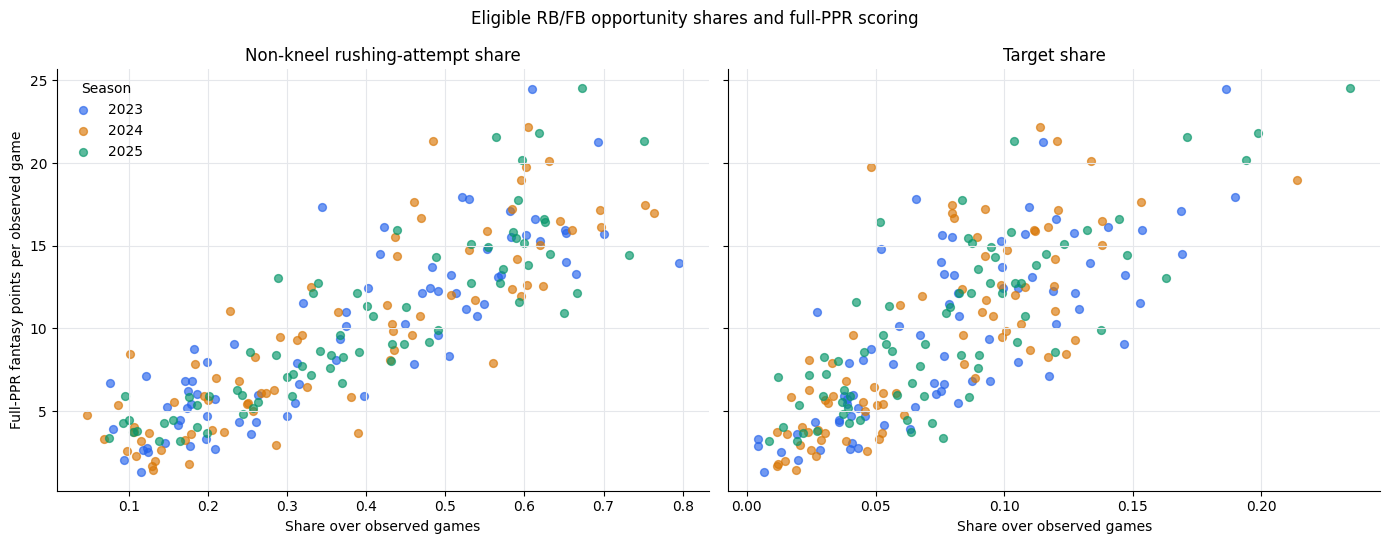

In [18]:
plot_population = gold_rb_season_features.loc[
    gold_rb_season_features["percentile_eligible"]
].copy()

season_colors = {
    2023: "#2563eb",
    2024: "#d97706",
    2025: "#059669",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
plot_definitions = [
    ("rush_attempt_share", "Non-kneel rushing-attempt share"),
    ("target_share", "Target share"),
]

for axis, (share_column, title) in zip(axes, plot_definitions):
    for season in SEASONS:
        season_rows = plot_population.loc[plot_population["season"].eq(season)]
        axis.scatter(
            season_rows[share_column].astype("float64"),
            season_rows["ppr_fantasy_points_per_game"].astype("float64"),
            label=str(season),
            color=season_colors[season],
            alpha=0.65,
            s=32,
        )
    axis.set_title(title)
    axis.set_xlabel("Share over observed games")
    axis.grid(color="#e5e7eb", linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Full-PPR fantasy points per observed game")
axes[0].legend(title="Season", frameon=False)
fig.suptitle("Eligible RB/FB opportunity shares and full-PPR scoring")
fig.tight_layout()
plt.show()

### 18. Persist season-partitioned Gold Parquet

Each partition is written and immediately reloaded. Shape, column order, dtypes, season membership, and the declared player-season grain must survive the round trip.

In [19]:
GOLD_RB_SEASON_DIR.mkdir(parents=True, exist_ok=True)

output_records = []
for season in SEASONS:
    season_partition = (
        gold_rb_season_features.loc[gold_rb_season_features["season"].eq(season)]
        .sort_values(["display_name", "player_id"])
        .reset_index(drop=True)
    )
    output_path = GOLD_RB_SEASON_DIR / f"rb_season_features_{season}.parquet"
    season_partition.to_parquet(output_path, index=False)
    reloaded = pd.read_parquet(output_path)

    assert reloaded.shape == season_partition.shape
    assert reloaded.columns.tolist() == season_partition.columns.tolist()
    assert reloaded.dtypes.astype(str).tolist() == season_partition.dtypes.astype(str).tolist()
    assert set(reloaded["season"].unique()) == {season}
    assert not reloaded.duplicated(GOLD_GRAIN).any()

    output_records.append(
        {
            "dataset": "gold_rb_season_features",
            "season": season,
            "rows": len(reloaded),
            "columns": len(reloaded.columns),
            "eligible_rows": int(reloaded["percentile_eligible"].sum()),
            "grain": " + ".join(GOLD_GRAIN),
            "duplicate_grain_rows": reloaded.duplicated(GOLD_GRAIN).sum(),
            "file_mb": output_path.stat().st_size / 1024**2,
            "round_trip_passed": True,
        }
    )

output_summary = pd.DataFrame(output_records)

assert output_summary["rows"].sum() == len(gold_rb_season_features)
assert output_summary["eligible_rows"].sum() == gold_rb_season_features["percentile_eligible"].sum()
assert output_summary["duplicate_grain_rows"].eq(0).all()
assert output_summary["round_trip_passed"].all()

output_summary

,dataset,season,rows,columns,eligible_rows,grain,duplicate_grain_rows,file_mb,round_trip_passed
0,gold_rb_season_features,2023,167,98,75,player_id + season,0,0.113589,True
1,gold_rb_season_features,2024,164,98,76,player_id + season,0,0.111916,True
2,gold_rb_season_features,2025,167,98,70,player_id + season,0,0.112253,True


In [20]:
print(
    f"Wrote {len(output_summary):,} RB Draft Gold files with "
    f"{output_summary['rows'].sum():,} player-seasons, "
    f"{len(gold_rb_season_features.columns):,} columns, "
    f"{output_summary['eligible_rows'].sum():,} percentile-eligible rows, and "
    f"{output_summary['file_mb'].sum():.2f} MB on disk."
)

Wrote 3 RB Draft Gold files with 498 player-seasons, 98 columns, 221 percentile-eligible rows, and 0.34 MB on disk.


## Takeaways

- `gold_rb_season_features` contains 498 regular-season RB/FB profiles at `player_id + season`: 167 in 2023, 164 in 2024, and 167 in 2025.
- All observed seasons remain available. The 20 seasons without weekly-stat evidence preserve null official production, touches, and fantasy scoring while retaining confirmed zero PBP opportunity.
- The eight-game and 50-opportunity rule identifies 221 percentile-eligible seasons. All ten percentile columns remain null for the 277 retained ineligible seasons.
- Official carries remain distinct from canonical non-kneel and designed rushes. The canonical total remains one below the official total because the documented Ogunbowale 2024 Week 15 source play stays excluded.
- Twenty-two multi-team player-seasons are combined without violating the player-season grain. Final position is `RB` for 463 seasons and `FB` for 35, while `positions_observed` preserves cross-position context.
- Full-PPR scoring remains transparent through receiving, rushing, special-teams, and fumble-lost components. The leading totals are Christian McCaffrey with 391.3 in 2023, Jahmyr Gibbs with 362.9 in 2024, and Christian McCaffrey with 416.6 in 2025.
- Nine season-total opportunity shares preserve rushing, receiving, red-zone, goal-line, end-zone, non-kneel, and designed-work definitions without averaging weekly percentages.
- Three 98-column season partitions pass total reconciliation, known-exception, eligibility, null behavior, schema, dtype, season, grain, and Parquet round-trip checks.